In [ ]:
import pandas as pd

df_teste = pd.DataFrame({
    "nome": ["Jonas", "Ana", "Roberto", "Samuel", "Breno", "Alexandre"],
    "idade": [28, 15, 35, 29, 30, 49]
})

df_teste

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Jonasjkb/analise-dados-mental-health/refs/heads/main/data/raw_mental_health.csv")

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   str    
 3   Academic_Level                1705 non-null   str    
 4   Country                       1705 non-null   str    
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   str    
 7   Affects_Academic_Performance  1705 non-null   str    
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 212.3 KB


Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

In [5]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


In [6]:
df.describe(include=object)

C:\Users\Jonas\AppData\Local\Temp\ipykernel_16896\3998025828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=object)


,Gender,Academic_Level,Country,Most_Used_Platform,Affects_Academic_Performance,Overall_Impact
count,1705,1705,1705,1705,1705,1705
unique,2,3,111,12,2,3
top,Male,Undergraduate,Other,Instagram,Yes,Negative
freq,878,721,667,389,1011,939


In [8]:
df.shape

(1705, 11)

In [9]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Overall_Impact'],
      dtype='str')

In [10]:
df = df.rename(columns={
    'Student_ID': 'ID_Aluno',
    'Age': 'Idade',
    'Gender': 'Gênero',
    'Academic_Level': 'Nível_Acadêmico',
    'Country': 'País',
    'Avg_Daily_Usage_Hours': 'Média_Horas_Uso_Diário',
    'Most_Used_Platform': 'Plataforma_Mais_Utilizada',
    'Affects_Academic_Performance': 'Afeta_Desempenho_Acadêmico',
    'Sleep_Hours_Per_Night': 'Horas_Sono_Por_Noite',
    'Mental_Health_Score': 'Pontuação_Saúde_Mental',
    'Overall_Impact': 'Impacto_Geral'
})

df.columns

Index(['ID_Aluno', 'Idade', 'Gênero', 'Nível_Acadêmico', 'País',
       'Média_Horas_Uso_Diário', 'Plataforma_Mais_Utilizada',
       'Afeta_Desempenho_Acadêmico', 'Horas_Sono_Por_Noite',
       'Pontuação_Saúde_Mental', 'Impacto_Geral'],
      dtype='str')

In [16]:
df.columns = (
    df.columns
      .str.strip()
      .str.upper()
      .str.replace(" ", "_")
)

df.columns

Index(['ID_ALUNO', 'IDADE', 'GÊNERO', 'NÍVEL_ACADÊMICO', 'PAÍS',
       'MÉDIA_HORAS_USO_DIÁRIO', 'PLATAFORMA_MAIS_UTILIZADA',
       'AFETA_DESEMPENHO_ACADÊMICO', 'HORAS_SONO_POR_NOITE',
       'PONTUAÇÃO_SAÚDE_MENTAL', 'IMPACTO_GERAL'],
      dtype='str')

In [18]:
df["GÊNERO"].value_counts()

GÊNERO
Male      878
Female    827
Name: count, dtype: int64

In [20]:
df["GÊNERO"] = df["GÊNERO"].replace({
    'Male': 'Masculino',
    'Female': 'Feminino'
})

df["GÊNERO"]

0       Masculino
1        Feminino
2       Masculino
3       Masculino
4        Feminino
          ...    
1700     Feminino
1701    Masculino
1702     Feminino
1703    Masculino
1704     Feminino
Name: GÊNERO, Length: 1705, dtype: str

In [24]:
df["NÍVEL_ACADÊMICO"].unique()

<ArrowStringArray>
['Graduação', 'Pós-graduação', 'Ensino Médio']
Length: 3, dtype: str

In [23]:
df["NÍVEL_ACADÊMICO"] = df["NÍVEL_ACADÊMICO"].replace({
    'Undergraduate': 'Graduação',
    'Graduate': 'Pós-graduação',
    'High School': 'Ensino Médio'
})

In [25]:
df["PAÍS"].unique()

<ArrowStringArray>
[      'Other',      'Canada',         'USA',       'India',   'Australia',
          'UK',     'Germany',  'Bangladesh',      'Brazil',       'Japan',
 ...
     'Lebanon',        'Iraq',       'Yemen',       'Syria', 'Afghanistan',
    'Pakistan',       'Nepal',      'Bhutan',   'Sri Lanka',    'Maldives']
Length: 111, dtype: str

In [37]:
from deep_translator import GoogleTranslator

# Pegue os valores únicos da coluna PAÍS
paises_unicos = df["PAÍS"].unique()

# Crie um dicionário de tradução
mapa_traducao = {}
for pais in paises_unicos:
    traducao = GoogleTranslator(source="en", target="pt").translate(pais)
    mapa_traducao[pais] = traducao

# Aplique o mapeamento no DataFrame
df["PAÍS"] = df["PAÍS"].replace(mapa_traducao)

# Conferir resultado
print(df["PAÍS"].unique())

<ArrowStringArray>
[      'Outro',      'Canadá',         'EUA',       'Índia',   'Austrália',
 'Reino Unido',    'Alemanha',  'Bangladesh',      'Brasil',       'Japão',
 ...
      'Líbano',      'Iraque',       'Iémen',       'Síria', 'Afeganistão',
   'Paquistão',       'Nepal',       'Butão',   'Sri Lanka',    'Maldivas']
Length: 110, dtype: str


In [39]:
df["PAÍS"].unique()

<ArrowStringArray>
[      'Outro',      'Canadá',         'EUA',       'Índia',   'Austrália',
 'Reino Unido',    'Alemanha',  'Bangladesh',      'Brasil',       'Japão',
 ...
      'Líbano',      'Iraque',       'Iémen',       'Síria', 'Afeganistão',
   'Paquistão',       'Nepal',       'Butão',   'Sri Lanka',    'Maldivas']
Length: 110, dtype: str

In [51]:
df.head()

,ID_ALUNO,IDADE,GÊNERO,NÍVEL_ACADÊMICO,PAÍS,MÉDIA_HORAS_USO_DIÁRIO,PLATAFORMA_MAIS_UTILIZADA,AFETA_DESEMPENHO_ACADÊMICO,HORAS_SONO_POR_NOITE,PONTUAÇÃO_SAÚDE_MENTAL,IMPACTO_GERAL,USO_SEVERO,SONO_RUIM
0,232,21,Masculino,Graduação,Outro,4.0,Facebook,Não,6.7,6.8,Neutro,False,False
1,564,23,Feminino,Graduação,Outro,1.6,LinkedIn,Não,8.6,7.6,Positivo,False,False
2,788,22,Masculino,Pós-graduação,Canadá,4.6,Instagram,Não,6.7,7.0,Neutro,False,False
3,686,18,Masculino,Graduação,Outro,7.0,Snapchat,Sim,5.4,5.3,Negativo,True,False
4,608,24,Feminino,Ensino Médio,Outro,7.5,Facebook,Sim,5.0,4.4,Negativo,True,False


In [43]:
df["AFETA_DESEMPENHO_ACADÊMICO"].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [44]:
df["AFETA_DESEMPENHO_ACADÊMICO"] = df["AFETA_DESEMPENHO_ACADÊMICO"].replace({
    'No': 'Não',
    'Yes': 'Sim'
})

df["AFETA_DESEMPENHO_ACADÊMICO"].unique()

<ArrowStringArray>
['Não', 'Sim']
Length: 2, dtype: str

In [46]:
df["IMPACTO_GERAL"].unique()

<ArrowStringArray>
['Neutral', 'Positive', 'Negative']
Length: 3, dtype: str

In [47]:
df["IMPACTO_GERAL"] = df["IMPACTO_GERAL"].replace({
    'Neutral': 'Neutro',
    'Positive': 'Positivo',
    'Negative': 'Negativo'
})

df["IMPACTO_GERAL"].unique()

<ArrowStringArray>
['Neutro', 'Positivo', 'Negativo']
Length: 3, dtype: str

In [49]:
df["USO_SEVERO"].unique()

array([False,  True])

In [50]:
df["USO_SEVERO"] = df["USO_SEVERO"].replace({
    'False': 'Falso',
    'True': 'Verdadeiro'
})

df["USO_SEVERO"].unique()

array([False,  True])

In [58]:
df.head()

,ID_ALUNO,IDADE,GÊNERO,NÍVEL_ACADÊMICO,PAÍS,MÉDIA_HORAS_USO_DIÁRIO,PLATAFORMA_MAIS_UTILIZADA,AFETA_DESEMPENHO_ACADÊMICO,HORAS_SONO_POR_NOITE,PONTUAÇÃO_SAÚDE_MENTAL,IMPACTO_GERAL,USO_SEVERO,SONO_RUIM,FAIXA_USO
0,232,21,Masculino,Graduação,Outro,4.0,Facebook,Não,6.7,6.8,Neutro,False,False,2-4h
1,564,23,Feminino,Graduação,Outro,1.6,LinkedIn,Não,8.6,7.6,Positivo,False,False,0-2h
2,788,22,Masculino,Pós-graduação,Canadá,4.6,Instagram,Não,6.7,7.0,Neutro,False,False,4-6h
3,686,18,Masculino,Graduação,Outro,7.0,Snapchat,Sim,5.4,5.3,Negativo,True,False,6-8h
4,608,24,Feminino,Ensino Médio,Outro,7.5,Facebook,Sim,5.0,4.4,Negativo,True,False,6-8h


In [54]:
df.groupby("MÉDIA_HORAS_USO_DIÁRIO")["PONTUAÇÃO_SAÚDE_MENTAL"].mean()

MÉDIA_HORAS_USO_DIÁRIO
1.5    8.220000
1.6    8.011111
1.7    8.063636
1.8    7.809091
1.9    8.133333
         ...   
8.1    5.180000
8.2    5.000000
8.3    4.870000
8.4    5.346154
8.5    5.033333
Name: PONTUAÇÃO_SAÚDE_MENTAL, Length: 71, dtype: float64

In [57]:
bins = [0, 2, 4, 6, 8, 10]
labels = ["0-2h", "2-4h", "4-6h", "6-8h", "8h+"]

df["FAIXA_USO"] = pd.cut(df["MÉDIA_HORAS_USO_DIÁRIO"], bins=bins, labels=labels)

df.groupby("FAIXA_USO")["PONTUAÇÃO_SAÚDE_MENTAL"].mean().round(2)

FAIXA_USO
0-2h    8.03
2-4h    7.62
4-6h    6.12
6-8h    4.93
8h+     5.10
Name: PONTUAÇÃO_SAÚDE_MENTAL, dtype: float64

In [ ]:
df.groupby("HORAS_SONO_POR_NOITE")["PONTUAÇÃO_SAÚDE_MENTAL"].mean()

In [60]:
df.groupby("SONO_RUIM")["PONTUAÇÃO_SAÚDE_MENTAL"].mean()

SONO_RUIM
False    6.317809
True     5.102083
Name: PONTUAÇÃO_SAÚDE_MENTAL, dtype: float64

In [61]:
df.groupby("AFETA_DESEMPENHO_ACADÊMICO")["MÉDIA_HORAS_USO_DIÁRIO"].mean()

AFETA_DESEMPENHO_ACADÊMICO
Não    4.070029
Sim    5.813155
Name: MÉDIA_HORAS_USO_DIÁRIO, dtype: float64

In [62]:
df.head()

,ID_ALUNO,IDADE,GÊNERO,NÍVEL_ACADÊMICO,PAÍS,MÉDIA_HORAS_USO_DIÁRIO,PLATAFORMA_MAIS_UTILIZADA,AFETA_DESEMPENHO_ACADÊMICO,HORAS_SONO_POR_NOITE,PONTUAÇÃO_SAÚDE_MENTAL,IMPACTO_GERAL,USO_SEVERO,SONO_RUIM,FAIXA_USO
0,232,21,Masculino,Graduação,Outro,4.0,Facebook,Não,6.7,6.8,Neutro,False,False,2-4h
1,564,23,Feminino,Graduação,Outro,1.6,LinkedIn,Não,8.6,7.6,Positivo,False,False,0-2h
2,788,22,Masculino,Pós-graduação,Canadá,4.6,Instagram,Não,6.7,7.0,Neutro,False,False,4-6h
3,686,18,Masculino,Graduação,Outro,7.0,Snapchat,Sim,5.4,5.3,Negativo,True,False,6-8h
4,608,24,Feminino,Ensino Médio,Outro,7.5,Facebook,Sim,5.0,4.4,Negativo,True,False,6-8h


In [63]:
df["PLATAFORMA_MAIS_UTILIZADA"].value_counts()

PLATAFORMA_MAIS_UTILIZADA
Instagram    389
TikTok       295
Facebook     256
LinkedIn     176
Twitter      170
YouTube      165
Snapchat     149
WhatsApp      54
WeChat        15
LINE          12
KakaoTalk     12
VKontakte     12
Name: count, dtype: int64

In [67]:
df.groupby("PLATAFORMA_MAIS_UTILIZADA")["PONTUAÇÃO_SAÚDE_MENTAL"].mean().round(2)

PLATAFORMA_MAIS_UTILIZADA
Facebook     6.43
Instagram    6.16
KakaoTalk    6.00
LINE         8.00
LinkedIn     6.60
Snapchat     6.05
TikTok       5.93
Twitter      6.30
VKontakte    7.00
WeChat       6.47
WhatsApp     5.54
YouTube      6.21
Name: PONTUAÇÃO_SAÚDE_MENTAL, dtype: float64

In [66]:
df.groupby("PLATAFORMA_MAIS_UTILIZADA")["HORAS_SONO_POR_NOITE"].mean().round(2)

PLATAFORMA_MAIS_UTILIZADA
Facebook     6.86
Instagram    6.80
KakaoTalk    7.05
LINE         8.35
LinkedIn     6.73
Snapchat     6.19
TikTok       6.36
Twitter      6.46
VKontakte    7.75
WeChat       7.36
WhatsApp     5.87
YouTube      6.43
Name: HORAS_SONO_POR_NOITE, dtype: float64

In [68]:
df.groupby("PAÍS")["PONTUAÇÃO_SAÚDE_MENTAL"].mean().sort_values(ascending=False)

PAÍS
Bahamas             8.0
Bahrein             8.0
Bielorrússia        8.0
Bolívia             8.0
Bósnia              8.0
                   ... 
Romênia             5.0
Síria               5.0
Tailândia           5.0
Uzbequistão         5.0
República Tcheca    4.0
Name: PONTUAÇÃO_SAÚDE_MENTAL, Length: 110, dtype: float64

In [69]:
df.corr(numeric_only=True)

,ID_ALUNO,IDADE,MÉDIA_HORAS_USO_DIÁRIO,HORAS_SONO_POR_NOITE,PONTUAÇÃO_SAÚDE_MENTAL,USO_SEVERO,SONO_RUIM
ID_ALUNO,1.000000,0.070681,0.063552,0.003809,-0.018457,0.087355,0.025332
IDADE,0.070681,1.000000,-0.053610,0.063745,0.083701,-0.042945,-0.038542
MÉDIA_HORAS_USO_DIÁRIO,0.063552,-0.053610,1.000000,-0.817444,-0.826391,0.838340,0.326630
HORAS_SONO_POR_NOITE,0.003809,0.063745,-0.817444,1.000000,0.785372,-0.748048,-0.489092
PONTUAÇÃO_SAÚDE_MENTAL,-0.018457,0.083701,-0.826391,0.785372,1.000000,-0.746865,-0.263635
USO_SEVERO,0.087355,-0.042945,0.838340,-0.748048,-0.746865,1.000000,0.263097
SONO_RUIM,0.025332,-0.038542,0.326630,-0.489092,-0.263635,0.263097,1.000000


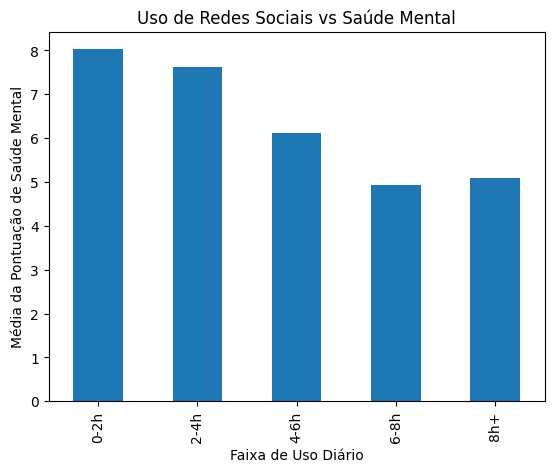

In [70]:
import matplotlib.pyplot as plt

df.groupby("FAIXA_USO")["PONTUAÇÃO_SAÚDE_MENTAL"].mean().plot(kind="bar")

plt.title("Uso de Redes Sociais vs Saúde Mental")
plt.xlabel("Faixa de Uso Diário")
plt.ylabel("Média da Pontuação de Saúde Mental")
plt.show()

In [96]:
import plotly.express as px

df_mean_uso_saude = df.groupby("FAIXA_USO")["PONTUAÇÃO_SAÚDE_MENTAL"].mean().round(2).reset_index()

fig = px.bar(
    df_mean_uso_saude,
    x="FAIXA_USO",
    y="PONTUAÇÃO_SAÚDE_MENTAL",
    color="PONTUAÇÃO_SAÚDE_MENTAL",
    color_continuous_scale="RdYlGn",
    title="Impacto do Uso de Redes Sociais na Saúde Mental"
)

fig.update_traces(texttemplate='%{y:.2f}', textposition='outside')

fig.update_layout(
    xaxis_title="Faixa de Uso Diário",
    yaxis_title="Média da Pontuação de Saúde Mental",
    title_x=0.5
)

fig.show()

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["FAIXA_USO"])
plt.title("Boxplot Faixa de Uso")
plt.xlabel("Faixa de Uso")
plt.show()

In [84]:
df["FAIXA_USO"].value_counts()

FAIXA_USO
4-6h    678
6-8h    465
2-4h    442
8h+      61
0-2h     59
Name: count, dtype: int64

In [ ]:
px.box(
    df,
    x="FAIXA_USO",
    y="PONTUAÇÃO_SAÚDE_MENTAL",
    title="Distribuição da Saúde Mental por Faixa de Uso"
)

In [87]:
df.groupby("FAIXA_USO")["PONTUAÇÃO_SAÚDE_MENTAL"].median()

FAIXA_USO
0-2h    8.0
2-4h    7.9
4-6h    6.0
6-8h    5.0
8h+     5.0
Name: PONTUAÇÃO_SAÚDE_MENTAL, dtype: float64

In [98]:
df_median_uso_saude = df.groupby("FAIXA_USO")["PONTUAÇÃO_SAÚDE_MENTAL"].agg(["mean", "median"]).reset_index()

fig = px.bar(
    df_median_uso_saude,
    x="FAIXA_USO",
    y="median",
    color="median",
    color_continuous_scale="RdYlGn",
    title="Impacto do Uso de Redes Sociais na Saúde Mental"
)

fig.update_traces(texttemplate='%{y:.2f}', textposition='outside')

fig.update_layout(
    xaxis_title="Faixa de Uso Diário",
    yaxis_title="Média da Pontuação de Saúde Mental",
    title_x=0.5
)

fig.show()

In [104]:
df_melted = df_grouped.melt(
    id_vars="FAIXA_USO",
    value_vars=["mean", "median"],
    var_name="MÉTRICA",
    value_name="VALOR"
).round(2)

fig = px.bar(
    df_melted,
    x="FAIXA_USO",
    y="VALOR",
    color="MÉTRICA",
    barmode="group",
    title="Comparação entre Média e Mediana da Saúde Mental"
)

fig.update_traces(texttemplate='%{y:.2f}', textposition='outside')

fig.update_layout(
    xaxis_title="Faixa de Uso Diário",
    yaxis_title="Pontuação de Saúde Mental",
    title_x=0.5
)

fig.show()

In [ ]:
df.groupby("HORAS_SONO_POR_NOITE")["PONTUAÇÃO_SAÚDE_MENTAL"].median()

In [106]:
bins = [0, 4, 6, 8, 10]
labels = ["<4h", "4-6h", "6-8h", "8h+"]

df["FAIXA_SONO"] = pd.cut(df["HORAS_SONO_POR_NOITE"], bins=bins, labels=labels)

df.groupby("FAIXA_SONO")["PONTUAÇÃO_SAÚDE_MENTAL"].median()

FAIXA_SONO
<4h     5.00
4-6h    5.00
6-8h    6.75
8h+     8.00
Name: PONTUAÇÃO_SAÚDE_MENTAL, dtype: float64

In [107]:
df_median_sono_saude = df.groupby("FAIXA_SONO")["PONTUAÇÃO_SAÚDE_MENTAL"].median().reset_index()

fig = px.bar(
    df_median_sono_saude,
    x="FAIXA_SONO",
    y="PONTUAÇÃO_SAÚDE_MENTAL",
    color="PONTUAÇÃO_SAÚDE_MENTAL",
    color_continuous_scale="RdYlGn",
    title="Impacto das Horas de Sono na Saúde Mental"
)

fig.update_traces(texttemplate='%{y:.2f}', textposition='outside')

fig.update_layout(
    xaxis_title="Faixa de Sono por Noite",
    yaxis_title="Pontuação de Saúde Mental",
    title_x=0.5
)

fig.show()

In [108]:
df.groupby(["FAIXA_USO", "FAIXA_SONO"])["PONTUAÇÃO_SAÚDE_MENTAL"].median()

FAIXA_USO  FAIXA_SONO
0-2h       6-8h          8.00
           8h+           8.10
2-4h       4-6h          6.45
           6-8h          7.50
           8h+           8.00
4-6h       4-6h          5.50
           6-8h          6.40
           8h+           7.00
6-8h       4-6h          5.00
           6-8h          5.00
8h+        <4h           5.00
           4-6h          5.10
Name: PONTUAÇÃO_SAÚDE_MENTAL, dtype: float64

In [110]:
df_uso_sono_saude = df.groupby(
    ["FAIXA_USO", "FAIXA_SONO"]
)["PONTUAÇÃO_SAÚDE_MENTAL"].median().reset_index()

df_uso_sono_saude

,FAIXA_USO,FAIXA_SONO,PONTUAÇÃO_SAÚDE_MENTAL
0,0-2h,6-8h,8.00
1,0-2h,8h+,8.10
2,2-4h,4-6h,6.45
3,2-4h,6-8h,7.50
4,2-4h,8h+,8.00
5,4-6h,4-6h,5.50
6,4-6h,6-8h,6.40
7,4-6h,8h+,7.00
8,6-8h,4-6h,5.00
9,6-8h,6-8h,5.00


In [114]:
df_pivot = df_uso_sono_saude.pivot(
    index="FAIXA_SONO",
    columns="FAIXA_USO",
    values="PONTUAÇÃO_SAÚDE_MENTAL"
)

df_pivot = df_pivot.reindex(index=["<4h", "4-6h", "6-8h", "8h+"])
df_pivot = df_pivot[["0-2h", "2-4h", "4-6h", "6-8h", "8h+"]]

fig = px.imshow(
    df_pivot,
    text_auto=".2f",
    color_continuous_scale="RdYlGn",
    title="Impacto Combinado: Uso de Redes Sociais vs Sono"
)

fig.update_layout(
    xaxis_title="Faixa de Uso Diário",
    yaxis_title="Faixa de Sono por Noite",
    title_x=0.5
)

fig.show()

In [115]:
df.groupby("AFETA_DESEMPENHO_ACADÊMICO")["MÉDIA_HORAS_USO_DIÁRIO"].median()

AFETA_DESEMPENHO_ACADÊMICO
Não    3.8
Sim    5.8
Name: MÉDIA_HORAS_USO_DIÁRIO, dtype: float64

In [116]:
df.groupby(["FAIXA_USO", "AFETA_DESEMPENHO_ACADÊMICO"]).size().unstack()

AFETA_DESEMPENHO_ACADÊMICO,Não,Sim
FAIXA_USO,,
0-2h,51,8
2-4h,346,96
4-6h,215,463
6-8h,66,399
8h+,16,45


In [118]:
df.groupby(["FAIXA_USO", "AFETA_DESEMPENHO_ACADÊMICO"]).size().groupby(level=0).apply(lambda x: x / x.sum())

FAIXA_USO  FAIXA_USO  AFETA_DESEMPENHO_ACADÊMICO
0-2h       0-2h       Não                           0.864407
                      Sim                           0.135593
2-4h       2-4h       Não                           0.782805
                      Sim                           0.217195
4-6h       4-6h       Não                           0.317109
                      Sim                           0.682891
6-8h       6-8h       Não                           0.141935
                      Sim                           0.858065
8h+        8h+        Não                           0.262295
                      Sim                           0.737705
dtype: float64

In [119]:
df_desempenho_uso = (
    df.groupby(["FAIXA_USO", "AFETA_DESEMPENHO_ACADÊMICO"])
    .size()
    .reset_index(name="COUNT")
)

fig = px.bar(
    df_desempenho_uso,
    x="FAIXA_USO",
    y="COUNT",
    color="AFETA_DESEMPENHO_ACADÊMICO",
    barmode="stack",
    title="Impacto do Uso de Redes Sociais no Desempenho Acadêmico"
)

fig.update_layout(
    xaxis_title="Faixa de Uso Diário",
    yaxis_title="Quantidade de Estudantes",
    title_x=0.5
)

fig.show()

In [121]:
df.groupby("AFETA_DESEMPENHO_ACADÊMICO")["PONTUAÇÃO_SAÚDE_MENTAL"].median()

AFETA_DESEMPENHO_ACADÊMICO
Não    7.0
Sim    5.6
Name: PONTUAÇÃO_SAÚDE_MENTAL, dtype: float64

In [124]:
df_desempenho_pontuacao = df.groupby("AFETA_DESEMPENHO_ACADÊMICO")["PONTUAÇÃO_SAÚDE_MENTAL"].median().reset_index()

fig = px.bar(
    df_desempenho_pontuacao,
    x="AFETA_DESEMPENHO_ACADÊMICO",
    y="PONTUAÇÃO_SAÚDE_MENTAL",
    color="AFETA_DESEMPENHO_ACADÊMICO",
    text="PONTUAÇÃO_SAÚDE_MENTAL",
    color_discrete_map={
        "Sim": "red",
        "Não": "green"
    },
    title="Impacto do Desempenho Acadêmico na Saúde Mental"
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.update_layout(
    xaxis_title="Afeta o Desempenho Acadêmico?",
    yaxis_title="Mediana da Pontuação de Saúde Mental",
    title_x=0.5,
    showlegend=False
)

fig.show()

In [125]:
df["AFETA_DESEMPENHO_ACADÊMICO"].value_counts(normalize=True)

AFETA_DESEMPENHO_ACADÊMICO
Sim    0.592962
Não    0.407038
Name: proportion, dtype: float64

In [128]:
df.groupby("PLATAFORMA_MAIS_UTILIZADA")["PONTUAÇÃO_SAÚDE_MENTAL"].mean().sort_values(ascending=False).round(2)

PLATAFORMA_MAIS_UTILIZADA
LINE         8.00
VKontakte    7.00
LinkedIn     6.60
WeChat       6.47
Facebook     6.43
Twitter      6.30
YouTube      6.21
Instagram    6.16
Snapchat     6.05
KakaoTalk    6.00
TikTok       5.93
WhatsApp     5.54
Name: PONTUAÇÃO_SAÚDE_MENTAL, dtype: float64

In [132]:
df_plat_pont = (
    df.groupby("PLATAFORMA_MAIS_UTILIZADA")["PONTUAÇÃO_SAÚDE_MENTAL"]
    .mean()
    .reset_index()
    .sort_values(by="PONTUAÇÃO_SAÚDE_MENTAL", ascending=True)
    .round(2)
)

fig = px.bar(
    df_plat_pont,
    x="PONTUAÇÃO_SAÚDE_MENTAL",
    y="PLATAFORMA_MAIS_UTILIZADA",
    orientation="h",
    color="PONTUAÇÃO_SAÚDE_MENTAL",
    color_continuous_scale="RdYlGn",
    title="Saúde Mental por Plataforma Mais Utilizada"
)

fig.update_layout(
    xaxis_title="Pontuação de Saúde Mental",
    yaxis_title="Plataforma",
    title_x=0.5
)

fig.show()

In [137]:
df.groupby("PLATAFORMA_MAIS_UTILIZADA")[
    ["PONTUAÇÃO_SAÚDE_MENTAL", "MÉDIA_HORAS_USO_DIÁRIO"]
].mean().sort_values(by="PONTUAÇÃO_SAÚDE_MENTAL", ascending=True).round(2)

,PONTUAÇÃO_SAÚDE_MENTAL,MÉDIA_HORAS_USO_DIÁRIO
PLATAFORMA_MAIS_UTILIZADA,,
WhatsApp,5.54,6.48
TikTok,5.93,5.34
KakaoTalk,6.00,4.73
Snapchat,6.05,5.37
Instagram,6.16,5.00
YouTube,6.21,5.15
Twitter,6.30,5.16
Facebook,6.43,4.94
WeChat,6.47,4.96


In [138]:
df_plat_pont.nsmallest(3, "PONTUAÇÃO_SAÚDE_MENTAL")

,PLATAFORMA_MAIS_UTILIZADA,PONTUAÇÃO_SAÚDE_MENTAL
10,WhatsApp,5.54
6,TikTok,5.93
2,KakaoTalk,6.00
